In [1]:
import numpy as np
import pandas as pd

# data load

In [7]:
df = pd.read_csv('shape_detection_example_dataset.csv')
wafer_data = {
    wafer_id: group["PARAMETER_VALUE"].to_numpy()
    for wafer_id, group in df.groupby("WAFER_ID")
}

# method1

In [10]:
peak_indices = {}
for wafer_id, group in df.groupby('WAFER_ID')['PARAMETER_VALUE']:
    values = group.to_numpy()
    peak_idx = np.argmax(values)
    peak_indices[wafer_id] = peak_idx

# 평균 - 3표준편차로 임계값 설정 (예시)
peak_idx_values = np.array(list(peak_indices.values()))
thr = peak_idx_values.mean() - 3*peak_idx_values.std()
anomalies = [w for w, idx in peak_indices.items() if idx < thr]
print("피크가 너무 빠른 이상 웨이퍼:", anomalies)

피크가 너무 빠른 이상 웨이퍼: []


In [11]:
# wafer_data는 {wafer_id: PARAMETER_VALUE 시계열} 형태의 dict라고 가정
all_curves = np.column_stack(list(wafer_data.values()))
median_curve = np.median(all_curves, axis=1)
lower_band = np.percentile(all_curves, 5, axis=1)
upper_band = np.percentile(all_curves, 95, axis=1)

outliers = []
for wafer_id, series in wafer_data.items():
    series = np.array(series)
    if np.any(series < lower_band) or np.any(series > upper_band):
        outliers.append(wafer_id)
print("5~95% envelope 초과한 이상 곡선:", outliers)

5~95% envelope 초과한 이상 곡선: ['wafer1', 'wafer10', 'wafer11', 'wafer12', 'wafer13', 'wafer14', 'wafer15', 'wafer16', 'wafer17', 'wafer18', 'wafer19', 'wafer2', 'wafer20', 'wafer21', 'wafer22', 'wafer23', 'wafer24', 'wafer25', 'wafer26', 'wafer27', 'wafer28', 'wafer29', 'wafer3', 'wafer30', 'wafer31', 'wafer32', 'wafer33', 'wafer34', 'wafer35', 'wafer36', 'wafer37', 'wafer38', 'wafer39', 'wafer4', 'wafer40', 'wafer41', 'wafer42', 'wafer43', 'wafer44', 'wafer45', 'wafer46', 'wafer47', 'wafer48', 'wafer49', 'wafer5', 'wafer50', 'wafer51', 'wafer52', 'wafer53', 'wafer54', 'wafer55', 'wafer56', 'wafer57', 'wafer58', 'wafer6', 'wafer7', 'wafer8', 'wafer9']


In [12]:
import numpy as np

ref_pattern = median_curve  # 앞서 구한 정상 곡선 중앙값

def pearson_corr(a, b):
    a = a - a.mean(); b = b - b.mean()
    return np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b))

outliers = []
for wafer_id, series in wafer_data.items():
    series = np.array(series)
    corr = pearson_corr(series, ref_pattern)
    if corr < 0.8:
        outliers.append((wafer_id, corr))
print("상관계수 낮은 이상 웨이퍼:", outliers)

상관계수 낮은 이상 웨이퍼: [('wafer51', 0.7014397075722341), ('wafer52', 0.7115774677326098), ('wafer53', 0.7182174257710704), ('wafer54', 0.723493692945122), ('wafer55', 0.7096777018543395), ('wafer56', 0.7115646776059628), ('wafer57', 0.6990724497007395), ('wafer58', 0.7035804902925554)]


In [14]:
from sklearn.decomposition import PCA

# X: shape (n_wafers, time_length), wafer 시계열들을 행으로 쌓은 행렬
X = np.vstack([series for series in wafer_data.values()])
X_mean = X.mean(axis=0)
X_centered = X - X_mean

pca = PCA(n_components=5)
X_pcs = pca.fit_transform(X_centered)
X_reconst = pca.inverse_transform(X_pcs)
recon_errors = np.mean((X_centered - X_reconst)**2, axis=1)

threshold = np.percentile(recon_errors, 95)
outliers = [wafer_id for wafer_id, err in zip(wafer_data.keys(), recon_errors) if err > threshold]
print("재구성 오차 기반 이상 웨이퍼:", outliers)

재구성 오차 기반 이상 웨이퍼: ['wafer52', 'wafer54', 'wafer56']


In [15]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X_pcs[:, :2])  # 첫 2개 주성분 사용
cluster_sizes = np.bincount(labels)
anomaly_cluster = np.argmin(cluster_sizes)
anomaly_indices = np.where(labels == anomaly_cluster)[0]
anomaly_wafers = [list(wafer_data.keys())[i] for i in anomaly_indices]
print("작은 군집 (이상 추정):", anomaly_wafers)

작은 군집 (이상 추정): ['wafer51', 'wafer52', 'wafer53', 'wafer54', 'wafer55', 'wafer56', 'wafer57', 'wafer58']


C:\Users\HYKP\miniconda3\envs\python310\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [16]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(kernel='rbf', nu=0.14, gamma='scale')
pred = ocsvm.fit_predict(X_pcs[:, :3])
outlier_wafers = [w for w, p in zip(wafer_data.keys(), pred) if p == -1]
print("One-Class SVM 이상 탐지:", outlier_wafers)

One-Class SVM 이상 탐지: ['wafer14', 'wafer36', 'wafer40', 'wafer51', 'wafer52', 'wafer53', 'wafer55', 'wafer7']


In [17]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.14, random_state=0)
labels = iso.fit_predict(X)
outlier_wafers = [w for w, lbl in zip(wafer_data.keys(), labels) if lbl == -1]
print("IsolationForest 이상 탐지:", outlier_wafers)

IsolationForest 이상 탐지: ['wafer51', 'wafer52', 'wafer53', 'wafer54', 'wafer55', 'wafer56', 'wafer57', 'wafer58']


In [18]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.14)
y_pred = lof.fit_predict(X)
outliers = [w for w, p in zip(wafer_data.keys(), y_pred) if p == -1]
print("LOF 이상 탐지:", outliers)

LOF 이상 탐지: ['wafer51', 'wafer52', 'wafer53', 'wafer54', 'wafer55', 'wafer56', 'wafer57', 'wafer58']


In [19]:
from sklearn.covariance import EllipticEnvelope

ee = EllipticEnvelope(contamination=0.14, random_state=0)
y_pred = ee.fit_predict(X_pcs[:, :2])
outliers = [w for w, p in zip(wafer_data.keys(), y_pred) if p == -1]
print("EllipticEnvelope 이상 탐지:", outliers)

EllipticEnvelope 이상 탐지: ['wafer51', 'wafer52', 'wafer53', 'wafer54', 'wafer55', 'wafer56', 'wafer57', 'wafer58']


# method2

In [24]:
data_matrix = df['PARAMETER_VALUE'].values.reshape(-1, 402)

In [27]:
import skfda
import scipy
from skfda.preprocessing.dim_reduction import FPCA
#data_matrix = .values
import matplotlib.pyplot as plt

grid_points = np.linspace(start=0, stop=401, num=402)
fd = skfda.FDataGrid(
    data_matrix=data_matrix,
    grid_points=grid_points)

from scipy.stats import gaussian_kde

from skfda.datasets._samples_generators import make_gaussian_process
from skfda.misc.covariances import Exponential, Gaussian
from skfda.misc.metrics import l2_distance, l2_norm
from skfda.preprocessing.dim_reduction import FPCA

q = 1 # number of principle components
fpca_clean = FPCA(n_components=q)
fpca_clean.fit(fd)
fd_hat = fpca_clean.inverse_transform(
    fpca_clean.transform(fd)
)

err_train = l2_distance(
    fd,
    fd_hat
) / l2_norm(fd)

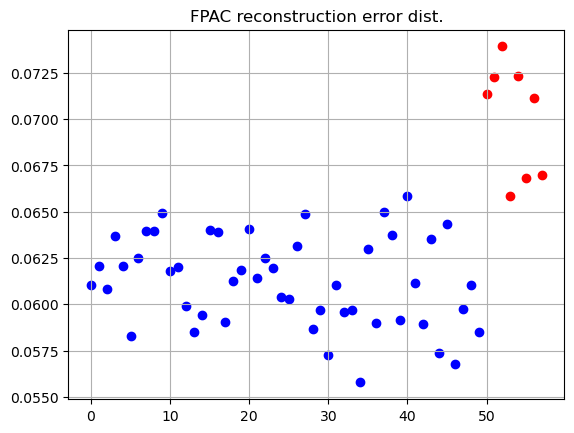

In [35]:
t = np.arange(len(err_train))
#thres = np.std(err_train, ddof=1) 

plt.title('FPAC reconstruction error dist.')
color='blue'
for idx, (x, y) in enumerate(zip(t, err_train)):
    if idx > 49:
        color='red'
    plt.scatter(x,y, color=color)
plt.grid(True)

In [36]:
mean = np.mean(data_matrix, axis=1)
rms = np.sqrt(np.mean(data_matrix**2, axis=1))
crest = np.max(np.abs(data_matrix), axis=1) / rms
shape = rms/mean
p2p = np.abs(np.max(data_matrix, axis=1) - np.min(data_matrix, axis=1))
impulse = p2p/mean
#cif = np.square(np.mean(np.sqrt(data_matrix), axis=1))
#margin = p2p / np.square(np.mean(np.sqrt(data_matrix), axis=1))
waveform_entropy = crest * np.log(crest)

data_stat = pd.DataFrame(
    data=[mean, rms, crest, shape, p2p, impulse, waveform_entropy],
    index=['mean', 'rms', 'crest', 'shape', 'p2p', 'impulse', 'waveform_entropy']
).T

data_stat.head()

,mean,rms,crest,shape,p2p,impulse,waveform_entropy
0,0.766948,0.811355,1.380743,1.057900,1.152517,1.502731,0.445457
1,0.766814,0.811640,1.393579,1.058458,1.220543,1.591708,0.462495
2,0.768985,0.813648,1.362459,1.058080,1.115999,1.451262,0.421396
3,0.764792,0.808267,1.388629,1.056845,1.192298,1.558985,0.455911
4,0.763554,0.807921,1.424278,1.058106,1.191146,1.560003,0.503717


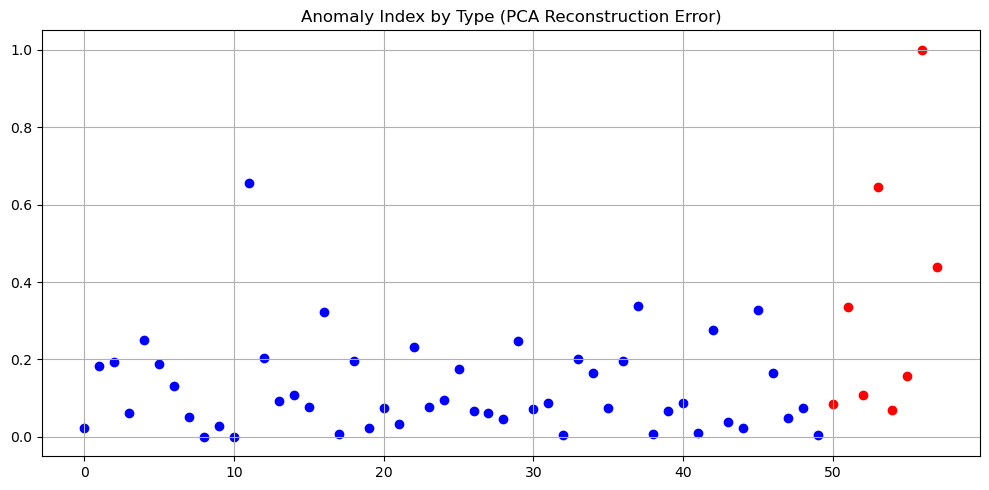

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
X_pca = pca.fit_transform(data_stat)

# 재구성 후 오차 계산 (anomaly index)
X_reconstructed = pca.inverse_transform(X_pca)
reconstruction_error = np.mean((data_stat - X_reconstructed) ** 2, axis=1)

# 재구성 오차 정규화하여 0~1로 스케일링 (anomaly index)
anomaly_index = (reconstruction_error - reconstruction_error.min()) / (reconstruction_error.max() - reconstruction_error.min())

t = np.arange(len(reconstruction_error))
plt.figure(figsize=(10, 5))
plt.scatter(t[:50], anomaly_index[:50], color='blue')
plt.scatter(t[50:], anomaly_index[50:], color='red')
plt.title("Anomaly Index by Type (PCA Reconstruction Error)")
plt.grid(True)
plt.tight_layout()
plt.show()

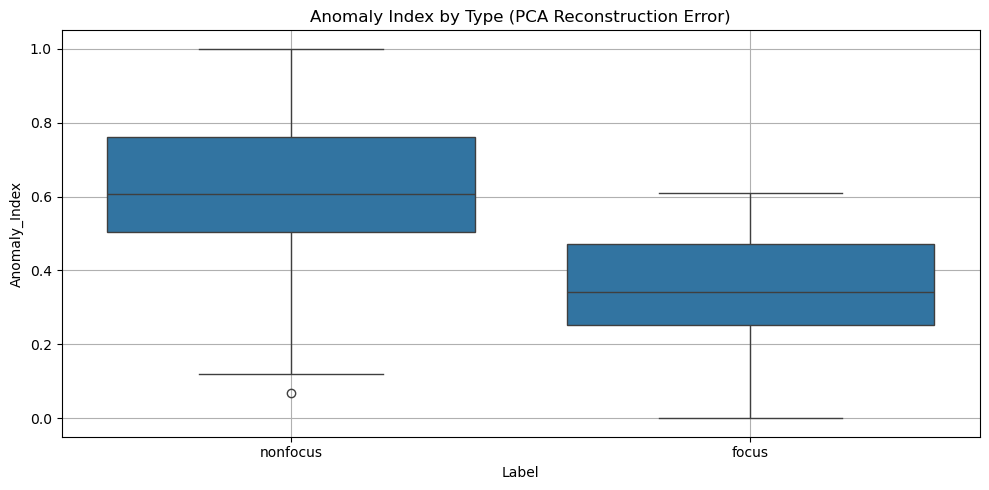

,WAFER_ID,Anomaly_Index,Label
0,wafer1,0.750980,nonfocus
1,wafer10,0.699955,nonfocus
2,wafer11,0.525078,nonfocus
3,wafer12,0.695207,nonfocus
4,wafer13,0.604970,nonfocus


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
#df = data

# 전처리: 각 wafer를 시계열로 재구성
# WAFER_ID별로 PARAMETER_VALUE 시계열을 추출
'''
wafer_data = {
    wafer_id: group["PARAMETER_VALUE"].to_numpy()
    for wafer_id, group in df.groupby("WAFER_ID")
}
'''

# 같은 길이를 가지도록 잘라내거나 보간하지 않고, 일단 길이 기준으로 정렬해 가장 짧은 길이에 맞춰 자름
min_length = min(len(v) for v in wafer_data.values())
wafer_data_trimmed = {
    k: v[:min_length] for k, v in wafer_data.items()
}

# 데이터 행렬로 변환 (wafer x time)
X = np.vstack([v for v in wafer_data_trimmed.values()])
wafer_ids = list(wafer_data_trimmed.keys())

# 정규화 (mean 0, std 1)
X_mean = X.mean(axis=1, keepdims=True)
X_std = X.std(axis=1, keepdims=True)
X_norm = (X - X_mean) / X_std

# 주성분 분석 (PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_norm)

# 재구성 후 오차 계산 (anomaly index)
X_reconstructed = pca.inverse_transform(X_pca)
reconstruction_error = np.mean((X_norm - X_reconstructed) ** 2, axis=1)

# 재구성 오차 정규화하여 0~1로 스케일링 (anomaly index)
anomaly_index = (reconstruction_error - reconstruction_error.min()) / (reconstruction_error.max() - reconstruction_error.min())

# 원래 데이터프레임에 anomaly index 붙이기
anomaly_df = pd.DataFrame({
    "WAFER_ID": wafer_ids,
    "Anomaly_Index": anomaly_index
})

# focus 여부 붙이기
label_map = df.drop_duplicates("WAFER_ID").set_index("WAFER_ID")["TYPE"].to_dict()
anomaly_df["Label"] = anomaly_df["WAFER_ID"].map(label_map)

# 시각화: anomaly index 분포
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(data=anomaly_df, x="Label", y="Anomaly_Index")
plt.title("Anomaly Index by Type (PCA Reconstruction Error)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 반환: anomaly_df 테이블 출력
anomaly_df.head()

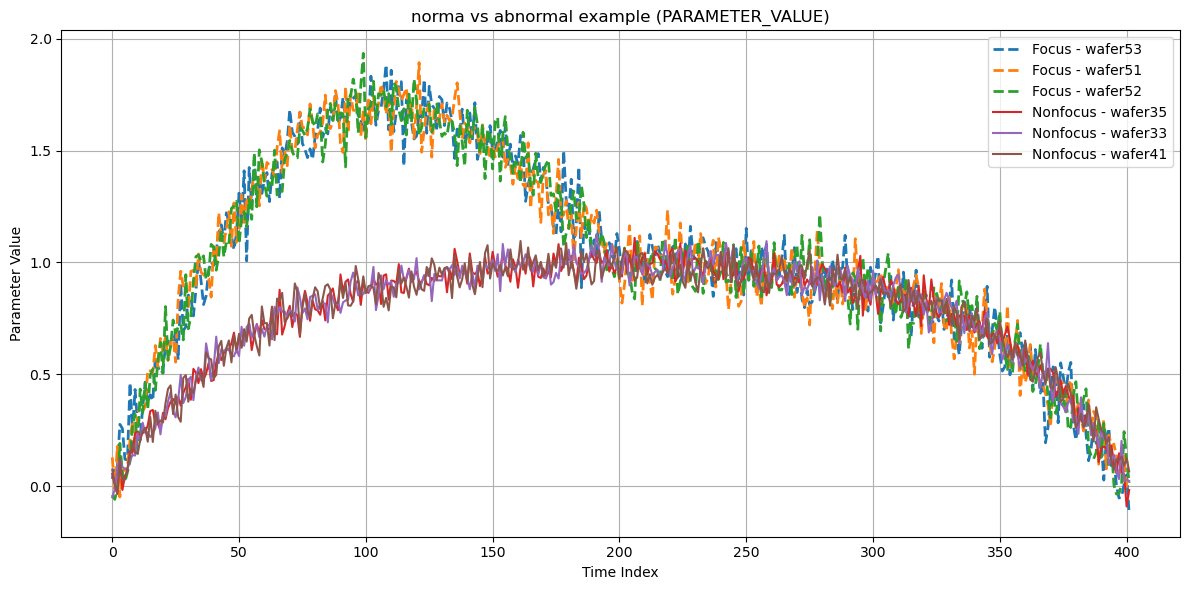

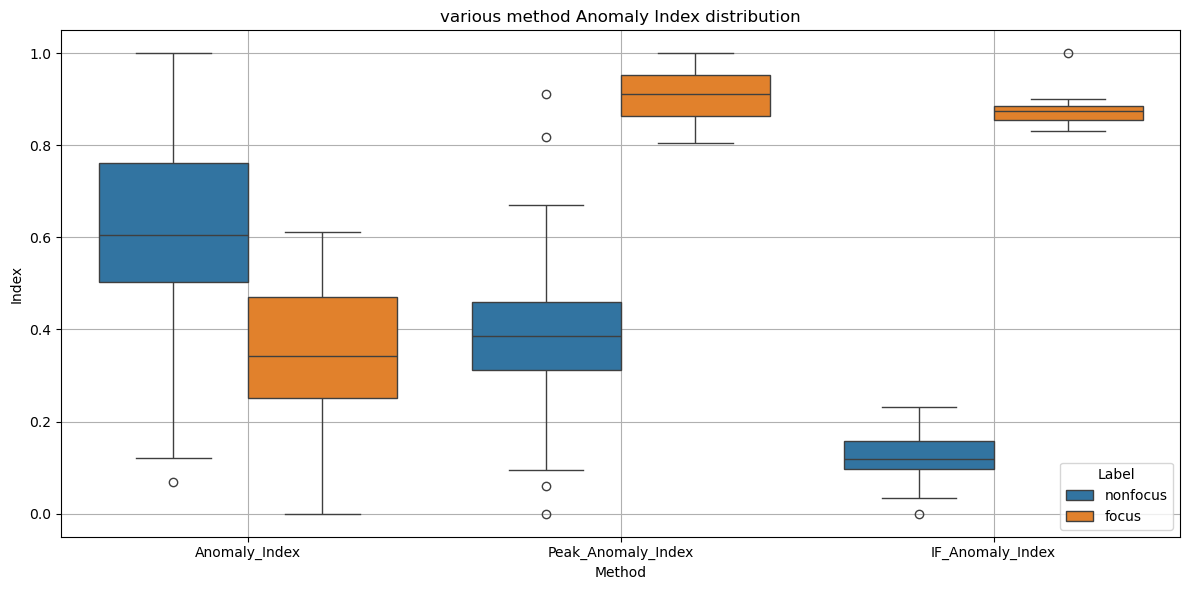

,WAFER_ID,Anomaly_Index,Label,Peak_Anomaly_Index,IF_Anomaly_Index
0,wafer1,0.750980,nonfocus,0.417647,0.119232
1,wafer10,0.699955,nonfocus,0.376471,0.097935
2,wafer11,0.525078,nonfocus,0.911765,0.120042
3,wafer12,0.695207,nonfocus,0.341176,0.108808
4,wafer13,0.604970,nonfocus,0.441176,0.099399
5,wafer14,0.540835,nonfocus,0.564706,0.150083
6,wafer15,0.477590,nonfocus,0.200000,0.165977
7,wafer16,1.000000,nonfocus,0.394118,0.181919
8,wafer17,0.766374,nonfocus,0.588235,0.116007
9,wafer18,0.357360,nonfocus,0.435294,0.139104


In [22]:
# 정상(focus 아님)과 이상(focus) 각각 3개씩 예시를 뽑아서 시계열 곡선 시각화

# focus와 nonfocus로 나눔
focus_ids = anomaly_df[anomaly_df["Label"] == "focus"].sort_values("Anomaly_Index", ascending=False)["WAFER_ID"].head(3).tolist()
nonfocus_ids = anomaly_df[anomaly_df["Label"] == "nonfocus"].sort_values("Anomaly_Index")["WAFER_ID"].head(3).tolist()

# 시계열 시각화
plt.figure(figsize=(12, 6))

# 비정상 곡선
for i, wid in enumerate(focus_ids):
    plt.plot(wafer_data_trimmed[wid], label=f"Focus - {wid}", linestyle="--", linewidth=2)

# 정상 곡선
for i, wid in enumerate(nonfocus_ids):
    plt.plot(wafer_data_trimmed[wid], label=f"Nonfocus - {wid}", linewidth=1.5)

plt.title("norma vs abnormal example (PARAMETER_VALUE)")
plt.xlabel("Time Index")
plt.ylabel("Parameter Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 다른 방법: 피크 인덱스를 기반으로 anomaly index 계산
peak_indices = np.array([
    np.argmax(wafer_data_trimmed[wid])
    for wid in wafer_ids
])

# 피크 인덱스를 정규화 (작을수록 이상)
peak_anomaly_index = (peak_indices.max() - peak_indices) / (peak_indices.max() - peak_indices.min())

# 결과 테이블에 추가
anomaly_df["Peak_Anomaly_Index"] = peak_anomaly_index

# Isolation Forest 기반 anomaly score
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.14, random_state=0)
iso_labels = iso.fit_predict(X_norm)
iso_scores = -iso.decision_function(X_norm)  # 클수록 이상

# 정규화
iso_index = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())
anomaly_df["IF_Anomaly_Index"] = iso_index

# 다시 시각화: 3가지 방법 비교 boxplot
melted = anomaly_df.melt(id_vars=["WAFER_ID", "Label"], 
                         value_vars=["Anomaly_Index", "Peak_Anomaly_Index", "IF_Anomaly_Index"],
                         var_name="Method", value_name="Index")

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x="Method", y="Index", hue="Label")
plt.title("various method Anomaly Index distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

# 갱신된 anomaly_df 테이블 표시
anomaly_df

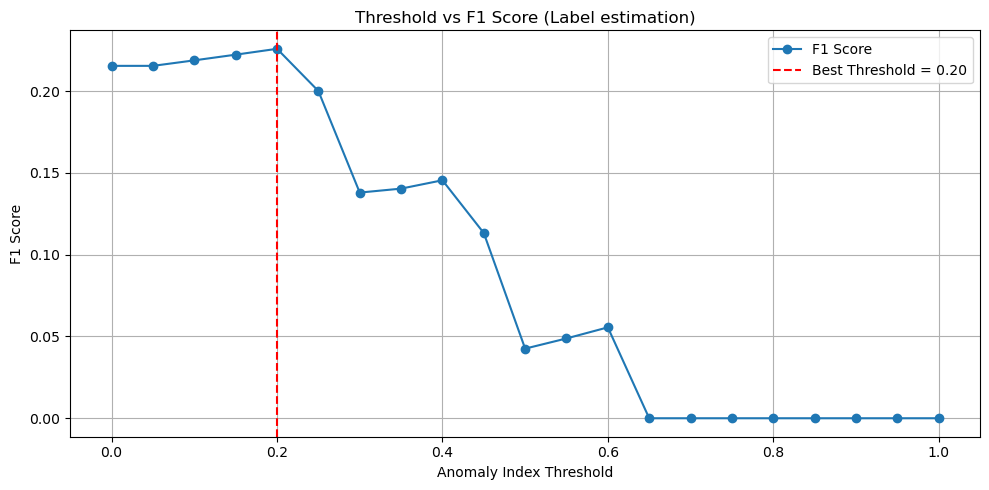

,WAFER_ID,Anomaly_Index,Label,Peak_Anomaly_Index,IF_Anomaly_Index
7,wafer16,1.000000,nonfocus,0.394118,0.181919
32,wafer39,0.938292,nonfocus,0.094118,0.048703
20,wafer28,0.927424,nonfocus,0.382353,0.164183
29,wafer36,0.908712,nonfocus,0.505882,0.168827
57,wafer9,0.905546,nonfocus,0.535294,0.097313
19,wafer27,0.886582,nonfocus,0.535294,0.145055
12,wafer20,0.863464,nonfocus,0.000000,0.230804
56,wafer8,0.831570,nonfocus,0.529412,0.127524
15,wafer23,0.793936,nonfocus,0.058824,0.190873
11,wafer2,0.790793,nonfocus,0.435294,0.146667


In [23]:

thresholds = np.linspace(0, 1, 21)  # 0.0 ~ 1.0 까지 21개 구간
results = []

for th in thresholds:
    pred = anomaly_df["Anomaly_Index"] > th
    tp = np.sum((pred == True) & (anomaly_df["Label"] == "focus"))
    fp = np.sum((pred == True) & (anomaly_df["Label"] == "nonfocus"))
    fn = np.sum((pred == False) & (anomaly_df["Label"] == "focus"))
    tn = np.sum((pred == False) & (anomaly_df["Label"] == "nonfocus"))
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    results.append((th, precision, recall, f1))

threshold_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])

# Best F1 기준 threshold 선택
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold = best_row["Threshold"]

# 이상 웨이퍼 Top-N 정렬
top_n = 10
top_anomalies = anomaly_df.sort_values("Anomaly_Index", ascending=False).head(top_n)

# 시각화: threshold 별 F1 score
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker='o', label="F1 Score")
plt.axvline(best_threshold, color='r', linestyle='--', label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Anomaly Index Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score (Label estimation)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 결과 리포트 출력
top_anomalies